In [1]:
#Loading the libraries
import numpy as np
import pandas as pd

In [2]:
#Load the dataset
df = pd.read_csv("/content/Products.csv")
df

,Product,Brand,Price,Stock,BestSeller
0,Monitor,EchoBoom,43625,182,True
1,Bluetooth Speaker,SoundMax,10067,117,True
2,Laptop,SkyLink,65982,152,False
3,Webcam,EchoBoom,44852,115,False
4,Headphones,TechNova,53477,61,False
5,Webcam,SkyLink,48180,104,False
6,USB Cable,ByteCore,45096,63,False
7,Wireless Earbuds,ByteCore,45812,82,True
8,USB Cable,VoltX,77217,173,True
9,Hard Drive,SkyLink,65798,146,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Product     50 non-null     object
 1   Brand       50 non-null     object
 2   Price       50 non-null     int64 
 3   Stock       50 non-null     int64 
 4   BestSeller  50 non-null     bool  
dtypes: bool(1), int64(2), object(2)
memory usage: 1.7+ KB


In [4]:
df.describe()
df.describe(include='object')

,Product,Brand
count,50,50
unique,19,10
top,Laptop,SkyLink
freq,5,7


In [5]:
df.columns

Index(['Product', 'Brand', 'Price', 'Stock', 'BestSeller'], dtype='object')

In [6]:
#To get the unique values from a column
df['Product'].unique()

array(['Monitor', 'Bluetooth Speaker', 'Laptop', 'Webcam', 'Headphones',
       'USB Cable', 'Wireless Earbuds', 'Hard Drive', 'SSD', 'Tablet',
       'Printer', 'Router', 'Drone', 'Projector', 'Smartwatch',
       'Gaming Mouse', 'Power Bank', 'Smartphone', 'Microphone'],
      dtype=object)

In [7]:
len(df['Product'].unique())

19

In [8]:
df['Product'].value_counts() #it gives the value counts from the table

,count
Product,
Laptop,5
Projector,4
Webcam,4
Smartphone,4
Monitor,3
SSD,3
Headphones,3
Wireless Earbuds,3
Drone,3


In [9]:
df['Brand'].value_counts()

,count
Brand,
SkyLink,7
VoltX,6
NextGen,6
SoundMax,5
ByteCore,5
TechNova,5
PixelPro,5
EchoBoom,4
TimeTrack,4


In [10]:
df['BestSeller'].unique()

array([ True, False])

In [11]:
df['BestSeller'].value_counts()

,count
BestSeller,
True,27
False,23


In [12]:
print(df['Price'].mean())
print(df['Price'].min())
print(df['Price'].max())

37894.24
1266
79898


In [13]:
print(df['Stock'].unique())

[182 117 152 115  61 104  63  82 173 146  24 116  81  42 127  66 109  83
  73  52 192  20 157 187  25  30  28 101 135  44  56 184  77  34 138 136
 145  70 143  94   5 169 130]


In [14]:
print(df['Stock'].mean())

92.42


In [15]:
df.dropna(); #-->Drop missing values from the dataframe
#fillna() -->Filling Missing values in the column

In [16]:
df[['Price','Product']];
df.loc[[10,20,30]][['Product','Brand']]

,Product,Brand
10,Laptop,NextGen
20,Projector,TechNova
30,Webcam,NovaTech


In [17]:
df.iloc[[10,20,30]][['Product','Brand']]

,Product,Brand
10,Laptop,NextGen
20,Projector,TechNova
30,Webcam,NovaTech


In [18]:
#Rename columns
df.rename(columns={'Product':'Product_Name'},inplace=True) #inplace will make permanent changes
df.columns

Index(['Product_Name', 'Brand', 'Price', 'Stock', 'BestSeller'], dtype='object')

In [19]:
#Finally u can also save the file as csv file
df.to_csv('Newdata.csv')

In [20]:
#Sort the values (Sorting)
df.sort_values("Price")
#Descending order
df.sort_values('Price',ascending=False)
#Ranking
df['Rank'] = df['Price'].rank() #by default it has method = "average"
df
df['Min_Rank'] = df['Price'].rank(method='min')
df

,Product_Name,Brand,Price,Stock,BestSeller,Rank,Min_Rank
0,Monitor,EchoBoom,43625,182,True,26.0,26.0
1,Bluetooth Speaker,SoundMax,10067,117,True,11.0,11.0
2,Laptop,SkyLink,65982,152,False,44.0,44.0
3,Webcam,EchoBoom,44852,115,False,27.0,27.0
4,Headphones,TechNova,53477,61,False,34.0,34.0
5,Webcam,SkyLink,48180,104,False,31.0,31.0
6,USB Cable,ByteCore,45096,63,False,28.0,28.0
7,Wireless Earbuds,ByteCore,45812,82,True,29.0,29.0
8,USB Cable,VoltX,77217,173,True,49.0,49.0
9,Hard Drive,SkyLink,65798,146,True,43.0,43.0


In [21]:
#grouping the data
print(df.groupby('Brand')['Price'].mean())
print(df.groupby('Brand')['Price'].sum())

Brand
ByteCore     31668.200000
EchoBoom     42746.250000
NextGen      35711.000000
NovaTech     39457.000000
PixelPro     43965.600000
SkyLink      49550.714286
SoundMax     11167.200000
TechNova     37860.800000
TimeTrack    31352.750000
VoltX        49252.500000
Name: Price, dtype: float64
Brand
ByteCore     158341
EchoBoom     170985
NextGen      214266
NovaTech     118371
PixelPro     219828
SkyLink      346855
SoundMax      55836
TechNova     189304
TimeTrack    125411
VoltX        295515
Name: Price, dtype: int64


In [22]:
#print(df.groupby('Brand')['Product_Name'].mean()) #fails with object type

In [23]:
#agg() func for multiple functions
df.groupby('Brand').agg({'Price':['min','max','mean']})

Price                     
             min    max          mean
Brand                                
ByteCore    4447  48817  31668.200000
EchoBoom    8318  74190  42746.250000
NextGen    10142  72236  35711.000000
NovaTech    1559  63799  39457.000000
PixelPro   19005  79898  43965.600000
SkyLink     8179  73788  49550.714286
SoundMax    2826  23211  11167.200000
TechNova    4649  64078  37860.800000
TimeTrack   2098  46200  31352.750000
VoltX       1266  77217  49252.500000

In [24]:
#Pivot table
df.pivot_table(values='Price',index='Brand',columns='BestSeller')

BestSeller,False,True
Brand,,
ByteCore,29632.500000,33025.333333
EchoBoom,44852.000000,42044.333333
NextGen,38060.666667,33361.333333
NovaTech,27286.000000,63799.000000
PixelPro,37674.666667,53402.000000
SkyLink,57081.000000,46538.600000
SoundMax,13589.500000,9552.333333
TechNova,31306.500000,64078.000000
TimeTrack,38556.500000,24149.000000


<Axes: title={'center': 'Product Prices'}, ylabel='Frequency'>

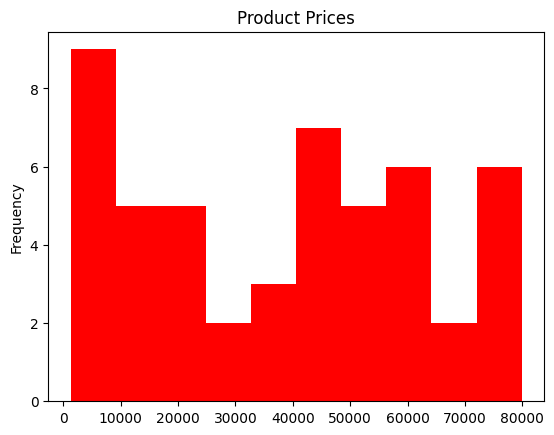

In [25]:
#Data Visualization
#df['Price'].plot(kind="hist")
df['Price'].plot(kind='hist',color='red',title="Product Prices")

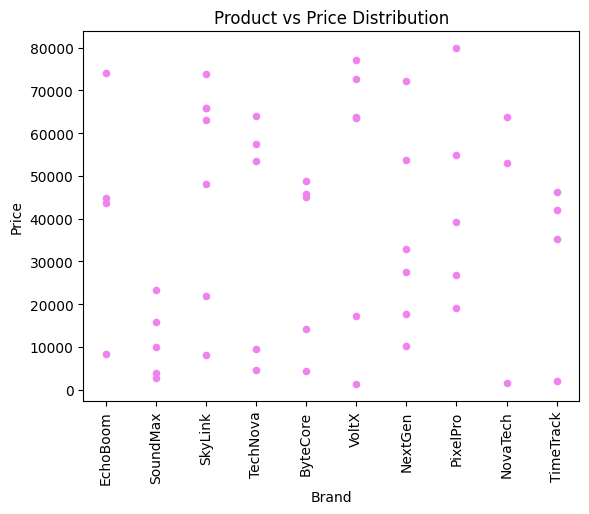

In [26]:
import matplotlib.pyplot as plt #matplotlib -->Mathematical plotting library
df.plot(x="Brand",
        y = "Price",kind="scatter",color = 'violet',
        title="Product vs Price Distribution")
plt.xticks(rotation=90)
plt.show()
#Use matplotlib -->line plot,bar plot,histogram,box plot,scatter plot,subplots

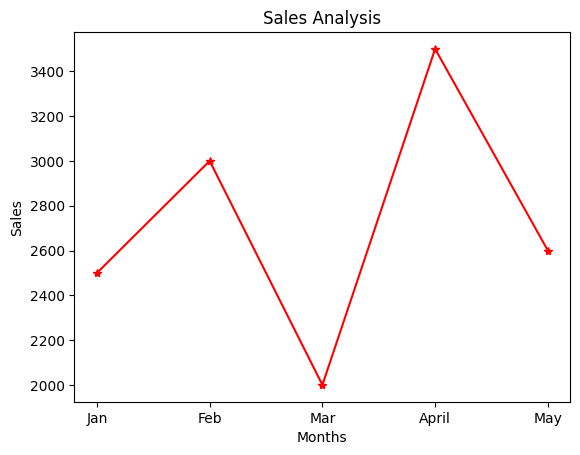

In [27]:
#Data Visualization --> Matplotlib
#Line Plot --> serial representation of data
months = ['Jan','Feb','Mar','April','May']
sales = [2500,3000,2000,3500,2600]
import matplotlib.pyplot as plt
#now we will use plot()
#plt.plot(months,sales)
plt.plot(months,sales,color='red',marker='*')
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Sales Analysis")
plt.show()

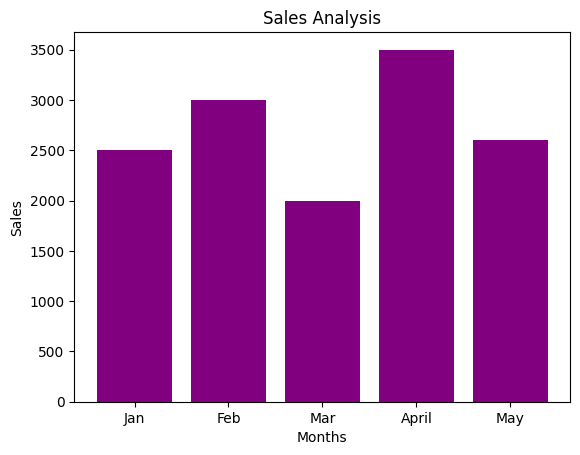

In [28]:
#bar plot -->rectangular bars over data
plt.bar(months,sales,color='purple')
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Sales Analysis")
plt.show()

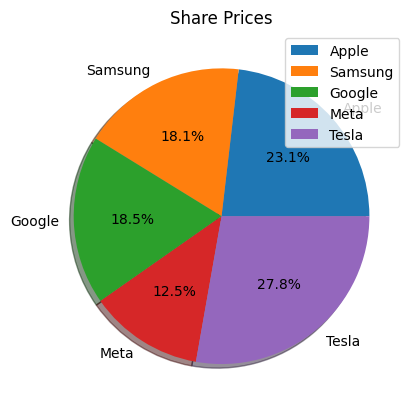

In [29]:
#Pie Chart -->proportions,percentages as slices over a circle
#Box Plot -->Box and whisker plot -->distribution mean,median (quartiles)
#subplots -->multiple plots
companies = ['Apple','Samsung','Google','Meta','Tesla']
shares = [250,195,200,135,300]
plt.pie(shares,labels=companies,
        autopct='%.1f%%',shadow=True)
plt.legend()
plt.title("Share Prices")
plt.show()

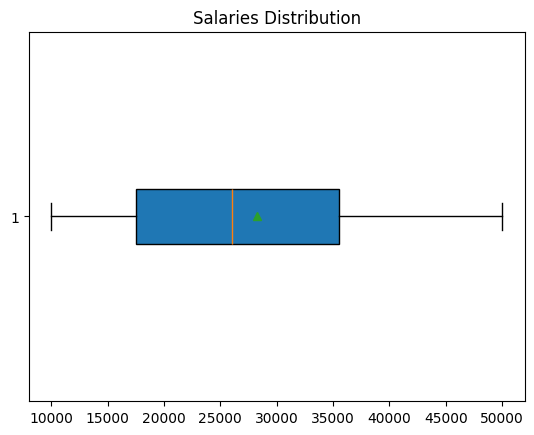

In [30]:
salaries = [25000,15000,26000,35000,15000,
            35682,45000,26050,50000,10000]
plt.boxplot(salaries,vert=False,showmeans = True,
            patch_artist=True)
plt.title("Salaries Distribution")
plt.show()

#subplot -->rows,columns,positions
1 2 -->

1 2 1
1 2 2

2 2

1 2
3 4

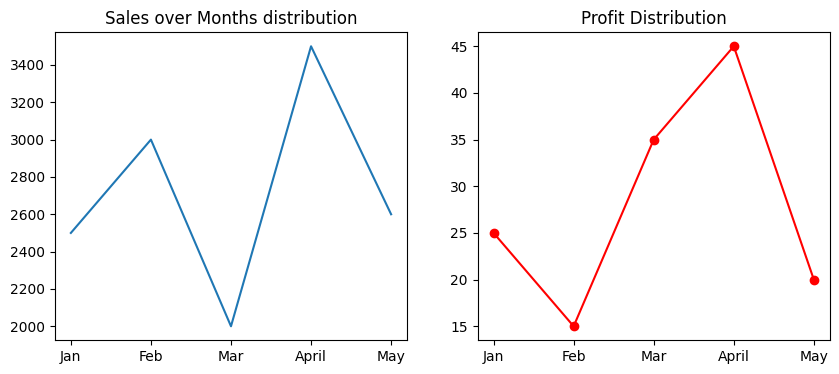

In [31]:
months = ['Jan','Feb','Mar','April','May']
sales = [2500,3000,2000,3500,2600]
profit = [25,15,35,45,20]
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(months,sales)
plt.title("Sales over Months distribution")
plt.subplot(1,2,2)
plt.plot(months,profit,color='red',marker='o')
plt.title("Profit Distribution")
plt.show()

#WebScraping --> It is the process of extraction of data from websites

#requests,BeautifulSoup
#pip install requests
#pip install bs4

-->We use requests module to connect to the website

-->It returns some status -->content

-->We use BeautifulSoup to extract the information from HTML code

-->Finally we can store in csv/.xlsx files...

In [32]:
#WebScraping
import requests
from bs4 import BeautifulSoup

In [33]:
url = "https://codegnan.com/"
g = requests.get(url) #returns the response as statuscode
g

<Response [200]>

In [34]:
print(g.status_code)

200


In [35]:
#g.content
soup = BeautifulSoup(g.text,'html')
#soup

In [36]:
title = soup.title.text
print(title)
print(type(title))

Codegnan: Online & classroom IT training institute (India)
<class 'str'>


In [37]:
headings = soup.find('h1').text
headings

'Where Talent  Meets Opportunity '

In [38]:
heading = soup.find('h3').text
heading

'4.5K+ Happy Students'

In [39]:
headings = soup.find_all('h3')
#print(headings)
for i in headings:
  print(i.text.strip()) #remove spaces

4.5K+ Happy Students
Batch Starts
Limited Seats
Batch Starts
Limited Seats
Hands-On Learning
Communication skills
Mock interviews
Placement focused Training
One to one mentoring
Practice sessions
Customised LMS
06-08-2026
Hyderabad
PFS-HYJ-040
06-08-2026
Hyderabad
JFS-HYJ-030
05-08-2026
Hyderabad
PFS-HYD-051
05-08-2026
Hyderabad
PFS-HYD-051
07-07-2026
Hyderabad
JFS-HYD-054
27-06-2026
Hyderabad
PFS-HYJ-040
Factorial Program in C: Code, Logic & Examples
Codegnan Celebrates 8 Years of Empowering India’s Next Generation of Tech Talent
Prime Number Program in C: Logic, Code & Examples
How to Start a Career in Software Testing (2026 Guide)
SQL Cheat Sheet (2026): Complete Syntax & Query Reference
Fibonacci Series in C: Program, Logic & Examples
Hackathon- Events- Communities - Workshops
Vijayawada
Hyderabad: JNTUH
Hyderabad: Ameerpet
Visakhapatnam
Our Courses in Vijayawada
Our Courses in  Hyderabad
Our Courses in Visakhapatnam


In [40]:
links = soup.find_all('a')
#links
for i in links[:20]:
  print(i.text.strip())

Skip to content

Programs
Codegnan LaunchPad
Codegnan Intensive Pro
Courses
Data Science with Agentic AI Course
Data Science with Agentic AI Course in Vijayawada
Data Science with Agentic AI Course in Visakhapatnam
Data Science with Agentic AI Course in Hyderabad
MERN Stack
MERN Stack Training Course in Vijayawada
MERN Stack Training Course in Hyderabad
Full Stack
Full Stack Course in Vijayawada
Full Stack Course in Hyderabad
Full Stack Course in Visakhapatnam
Python
Python Training in Hyderabad
Python Training in Vijayawada


In [42]:
#In similar way we can check with relevant tags -->'a',sections,images
links = soup.find_all("a")

for link in links[:10]:   # First 10 links
    print(link.get("href"))

#content
https://codegnan.com
https://codegnan.com/job-accelerator-program/
https://codegnan.com/launchpad/
https://codegnan.com/intensive-pro/
#
#
https://codegnan.com/courses/data-science-with-agentic-ai-course-in-vijayawada/
https://codegnan.com/courses/data-science-with-agentic-ai-course-in-visakhapatnam/
https://codegnan.com/courses/data-science-with-agentic-ai-course-in-hyderabad/


In [43]:
images = soup.find_all("img")

for image in images[:5]:
    print(image.get("src"))

https://codegnan.com/wp-content/w3-webp/uploads/2023/05/Codegnan-New-Logo.pngw3.webp
https://codegnan.com/wp-content/w3-webp/uploads/2026/04/students.pngw3.webp
data:image/svg+xml,%3Csvg%20xmlns='http://www.w3.org/2000/svg'%20width='24'%20height='24'%3E%3Crect%20width='100%25'%20height='100%25'%20opacity='0'/%3E%3C/svg%3E
data:image/svg+xml,%3Csvg%20xmlns='http://www.w3.org/2000/svg'%20width='24'%20height='24'%3E%3Crect%20width='100%25'%20height='100%25'%20opacity='0'/%3E%3C/svg%3E
data:image/svg+xml,%3Csvg%20xmlns='http://www.w3.org/2000/svg'%20width='28'%20height='24'%3E%3Crect%20width='100%25'%20height='100%25'%20opacity='0'/%3E%3C/svg%3E


In [44]:
description = soup.find("meta", attrs={"name": "description"})

if description:
    print("Description:")
    print(description.get("content"))

Description:
Codegnan offers finishing schools for students starting their career in tech. Become job-ready with our expert trainer led online and classroom IT courses.


In [45]:
meta_tags = soup.find_all("meta")

for tag in meta_tags:
    print(tag)

<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<meta content="index, follow, max-image-preview:large, max-snippet:-1, max-video-preview:-1" name="robots"/>
<meta content="Codegnan offers finishing schools for students starting their career in tech. Become job-ready with our expert trainer led online and classroom IT courses." name="description"/>
<meta content="en_US" property="og:locale"/>
<meta content="website" property="og:type"/>
<meta content="Codegnan: Online &amp; classroom IT training institute (India)" property="og:title"/>
<meta content="Codegnan offers finishing schools for students starting their career in tech. Become job-ready with our expert trainer led online and classroom IT courses." property="og:description"/>
<meta content="https://codegnan.com/" property="og:url"/>
<meta content="Codegnan" property="og:site_name"/>
<meta content="https://www.facebook.com/codegnan/" property="article:publisher"/>
<meta content="2026-08

In [46]:
menus = soup.find_all("li")

for menu in menus[:20]:
    print(menu.text.strip())

Programs

Codegnan LaunchPad
Codegnan Intensive Pro
Codegnan LaunchPad
Codegnan Intensive Pro
Courses

Data Science with Agentic AI Course

Data Science with Agentic AI Course in Vijayawada
Data Science with Agentic AI Course in Visakhapatnam
Data Science with Agentic AI Course in Hyderabad


MERN Stack

MERN Stack Training Course in Vijayawada
MERN Stack Training Course in Hyderabad


Full Stack

Full Stack Course in Vijayawada
Full Stack Course in Hyderabad
Full Stack Course in Visakhapatnam


Python

Python Training in Hyderabad
Python Training in Vijayawada


Python Full Stack

Python Full Stack Course in Hyderabad
Python Full Stack Course in Vijayawada


Java

Java Course in Hyderabad
Java Course in Vijayawada


Java Full Stack

Java Full Stack Course in Hyderabad
Java Full Stack Course in Vijayawada


Data Science

Data Science Course in Hyderabad
Data Analytics Course in Vijayawada
Data Science Course in Vijayawada


Machine Learning

Machine Learning Course in Hyderabad
Machine

In [47]:
paragraphs = soup.find_all("p")

for p in paragraphs[:10]:
    print(p.text.strip())

Starts Soon
Available
Know more
Starts Soon
Available
Know more
Building a strong ecosystem of skilled professionals shaping the future of technology.
Feedback from those who made it
I am truly thankful to Codegnan IT Solutions for granting me the chance to intern with their wonderful organization. This experience has been a fantastic journey of growth and learning for me as a student, and it wouldn’t have been possible without their valuable guidance and mentorship. I am a ML student here, the course curriculum is well made with theoretical and practical knowledge. Great staff who guide you with all possibilities by clarifying your doubts.
I had a really good experience learning with Codegnan, through the bootcamp conducted at our college MLR Institute of Technology. Our mentor Ravi Shiva Ram Teja Sir, he taught us with aa hands o n project which boosted our learning process. The bootcamp was learning about Frontend technologies like HTML,CSS,JS and in addition we worked with APIs and

In [48]:
buttons = soup.find_all("button")

for button in buttons:
    print(button.text.strip())

Join Community
Request a Callback
